<div style="background:linear-gradient(135deg,#4c1d95 0%,#6d28d9 55%,#a78bfa 100%);border-radius:18px;padding:32px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#ddd6fe;font-weight:700;text-transform:uppercase">Chapter 193 &middot; Capstone 31 &middot; Gradient Boosting</div>
  <div style="font-size:32px;font-weight:900;line-height:1.1;margin:10px 0 6px">Predicting Delivery Time</div>
  <div style="font-size:15px;color:#ddd6fe;max-width:820px;line-height:1.6">One engineered feature was worth a minute and a half. Switching model family was worth seventeen seconds. Twenty configurations of hyperparameter search were worth four. And the number the customer should see is not the prediction.</div>
</div>

In [1]:
import numpy as np, pandas as pd, warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
plt.rcParams.update({"figure.dpi":110,"font.size":11,"axes.spines.top":False,"axes.spines.right":False,
    "axes.grid":True,"grid.alpha":0.22,"axes.titleweight":"bold","axes.titlesize":12.5,"axes.titlelocation":"left"})
VI, DK, LT, MUT, GD, RD = "#6d28d9", "#4c1d95", "#a78bfa", "#94a3b8", "#047857", "#dc2626"

BASE = "https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
fn = "capstone-gradient-boosting-regression.xlsx"
def load(sheet):
    try:    return pd.read_excel("../../data/" + fn, sheet_name=sheet)
    except FileNotFoundError: return pd.read_excel(BASE + fn, sheet_name=sheet)
raw   = load("Data")
notes = load("Notes")
print("rows in the export:", f"{len(raw):,}")
raw.head()

rows in the export: 42,520


,order_id,order_day,day_of_week,hour_of_day,restaurant_id,cuisine,distance_km,items,order_value,rain_mm,traffic_index,couriers_available,orders_pending,courier_experience_days,delivery_minutes
0,700172,0,0,13,121,pizza,0.72,6,71.31,0.0,1.548,29,38,38,42.9
1,700247,0,0,18,119,salads,6.36,3,47.40,1.4,1.479,28,46,40,71.6
2,700343,0,0,12,23,burgers,0.97,4,59.32,0.0,1.291,27,38,385,38.3
3,700469,0,0,12,64,indian,4.12,4,62.86,0.0,1.459,29,33,29,54.7
4,700567,0,0,13,38,salads,4.11,1,28.63,0.0,1.501,28,47,41,79.7


## Step 1 &middot; The brief

The app shows an estimated arrival time when the order is placed. That number is a promise, and the whole project exists to decide what it should be.

In [2]:
for line in notes.Notes.fillna(""):
    print(line)

CAPSTONE 31 - PREDICTING DELIVERY TIME, AND WHAT NUMBER TO DISPLAY

Eighty-four days of orders from one city zone of a delivery platform.

THE DECISION. The app shows the customer an estimated arrival time when the order is
placed. That number is a promise, and the question is what to display.

WHAT BEING WRONG COSTS, from the operations team:
  arriving LATE   is roughly three times as costly as arriving the same amount EARLY.
  Late orders drive refunds, support contacts and churn. Early orders are mildly
  annoying and cost the courier a wait.
  The team's current service target is that no more than 15 percent of orders should
  arrive after the displayed time.

WHAT THE PLATFORM DOES NOW. It displays the model's point prediction plus a flat
8 minute buffer. Nobody remembers who chose 8.

THE BASELINE TO BEAT. A linear regression on the raw columns of this file. Any model
that does not beat it is not worth deploying, and the comparison must be on a
TIME-ORDERED split, because the mo

Two things in there deserve underlining before any modeling.

**Late is three times as costly as early.** So the loss function is not squared error and not absolute error. It is asymmetric, and an asymmetric loss has a known optimum that is not the mean.

**A linear regression on the raw columns is the baseline.** Not an aspiration, a hurdle. Everything below is measured against it.

## Step 2 &middot; Cleaning, and a split that respects time

In [3]:
d = raw.drop_duplicates(subset="order_id").copy()
print(f"raw rows                  {len(raw):,}")
print(f"after the duplicate export {len(d):,}")
d = d[d.delivery_minutes > 0]
print(f"excluding cancellations   {len(d):,}   (recorded as a delivery time of zero)")
d = d[d.distance_km < 900]
print(f"with usable GPS           {len(d):,}   (999 km is a sensor failure, not a long trip)")
d = d.sort_values(["order_day","order_id"]).reset_index(drop=True)

tr = (d.order_day < 70).values
va = ((d.order_day >= 70) & (d.order_day < 77)).values
te = (d.order_day >= 77).values
y  = d.delivery_minutes.values
print(f"\ntrain    days  0 to 69   {tr.sum():,} orders")
print(f"validate days 70 to 76   {va.sum():,} orders")
print(f"test     days 77 to 83   {te.sum():,} orders")
print(f"\ndelivery time: mean {y.mean():.1f} min   sd {y.std():.1f}   median {np.median(y):.1f}")

raw rows                  42,520
after the duplicate export 42,000
excluding cancellations   41,618   (recorded as a delivery time of zero)
with usable GPS           41,410   (999 km is a sensor failure, not a long trip)

train    days  0 to 69   34,462 orders
validate days 70 to 76   3,425 orders
test     days 77 to 83   3,523 orders

delivery time: mean 51.0 min   sd 17.9   median 49.4


Three windows, in time order. The model will always be predicting orders that have not happened yet, so the validation and test windows sit after the training window rather than being sampled from inside it.

The middle window does the choosing and the last one is opened once, at the end. That separation is the only thing that makes the final number believable, and section 5 shows what it is protecting against.

## Step 3 &middot; First look

Only the training window, days 0 to 69. Looking at the test set before the model is built is a small habit that becomes a large problem, and it costs nothing to form it here.

In [4]:
t = d[tr]
print("DELIVERY MINUTES, TRAINING WINDOW ONLY")
print(t.delivery_minutes.describe(percentiles=[.05,.25,.5,.75,.85,.95]).round(2).to_string())
print(f"\n  skewness {t.delivery_minutes.skew():+.3f}   kurtosis {t.delivery_minutes.kurtosis():+.3f}")
print(f"  the median is {t.delivery_minutes.median():.1f} min and the 85th percentile is "
      f"{t.delivery_minutes.quantile(0.85):.1f} min,")
print(f"  a gap of {t.delivery_minutes.quantile(0.85)-t.delivery_minutes.median():.1f} minutes on the same orders.")

print("\nBY HOUR OF DAY")
print(f"  {'hour':>5s} {'orders':>8s} {'median':>8s} {'85th':>8s}")
for h, g in t.groupby("hour_of_day"):
    if h % 2 == 0 or h in (12, 19):
        print(f"  {h:5d} {len(g):8,} {g.delivery_minutes.median():8.1f} "
              f"{g.delivery_minutes.quantile(0.85):8.1f}")

DELIVERY MINUTES, TRAINING WINDOW ONLY
count    34462.00
mean        51.01
std         17.89
min          6.00
5%          25.00
25%         38.20
50%         49.45
75%         61.60
85%         69.00
95%         82.80
max        174.30

  skewness +0.708   kurtosis +1.088
  the median is 49.5 min and the 85th percentile is 69.0 min,
  a gap of 19.5 minutes on the same orders.

BY HOUR OF DAY
   hour   orders   median     85th
     10    1,116     34.2     45.5
     12    3,242     54.7     72.3
     14    2,423     34.2     46.7
     16    1,335     34.3     46.8
     18    4,538     54.9     72.5
     19    5,270     55.1     73.5
     20    3,582     55.0     73.2
     22    1,115     33.6     46.5


**What this shows.** The distribution leans right: most orders land near the middle and a thin tail runs a long way past it. That single fact is why the last third of this notebook exists. A model fitted to squared error aims at the middle of that distribution, so roughly half of all orders arrive after whatever it predicts, and the orders in the tail are the ones that generate complaints. The hourly table says the tail is not spread evenly either.

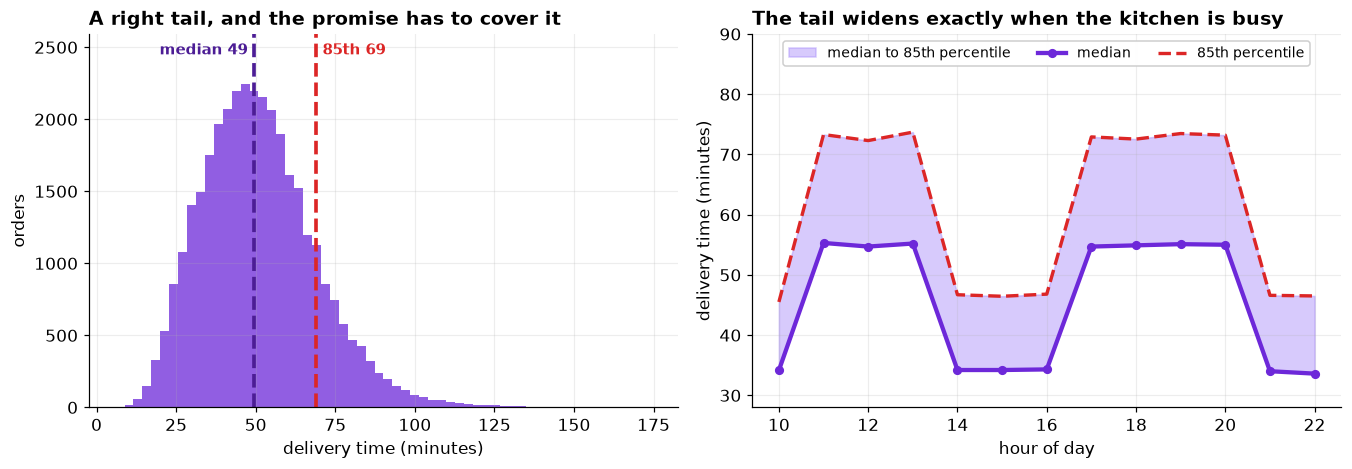

In [5]:
t = d[tr]
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.4))

ax = axes[0]
ax.hist(t.delivery_minutes, bins=60, color=VI, alpha=0.75)
med = t.delivery_minutes.median(); q85 = t.delivery_minutes.quantile(0.85)
top = ax.get_ylim()[1]
ax.set_ylim(0, top*1.10)
ax.axvline(med, color=DK, lw=2.4, ls="--")
ax.axvline(q85, color=RD, lw=2.4, ls="--")
ax.text(med - 2, top*1.04, f"median {med:.0f}", color=DK, fontsize=10,
        fontweight="bold", ha="right")
ax.text(q85 + 2, top*1.04, f"85th {q85:.0f}", color=RD, fontsize=10, fontweight="bold")
ax.set_xlabel("delivery time (minutes)"); ax.set_ylabel("orders")
ax.set_title("A right tail, and the promise has to cover it")

ax = axes[1]
hrs = sorted(t.hour_of_day.unique())
med_h = [t[t.hour_of_day==h].delivery_minutes.median() for h in hrs]
q85_h = [t[t.hour_of_day==h].delivery_minutes.quantile(0.85) for h in hrs]
ax.fill_between(hrs, med_h, q85_h, color=LT, alpha=0.45, label="median to 85th percentile")
ax.plot(hrs, med_h, color=VI, lw=2.8, marker="o", ms=5, label="median")
ax.plot(hrs, q85_h, color=RD, lw=2.2, ls="--", label="85th percentile")
ax.set_ylim(28, 90)
ax.set_xlabel("hour of day"); ax.set_ylabel("delivery time (minutes)")
ax.set_title("The tail widens exactly when the kitchen is busy")
ax.legend(fontsize=9, loc="upper center", ncol=3, framealpha=0.95)
plt.tight_layout(); plt.show()

**Left:** the bulk of orders sit in a tight band with a tail running out to the right. The two dashed lines are the whole decision in miniature: predict the median and half the orders are late, quote the 85th percentile and most are not. **Right:** the shaded band is that same gap, hour by hour. It is about twelve minutes wide in the mid-afternoon lull and about eighteen through both the lunch and the dinner peaks, which means a flat buffer added to every order is the wrong shape for the problem.

## Step 4 &middot; The baseline, and the same model with better features

In [6]:
RAW = ["order_day","day_of_week","hour_of_day","distance_km","items","order_value",
       "rain_mm","traffic_index","couriers_available","orders_pending","courier_experience_days"]
Xr = pd.get_dummies(d[RAW + ["cuisine"]], columns=["cuisine"], drop_first=True).astype(float)

def score(yt, yp): return np.sqrt(mean_squared_error(yt, yp)), mean_absolute_error(yt, yp)
def run(X, model, name):
    m = model.fit(X[tr], y[tr])
    rv, _  = score(y[va], m.predict(X[va]))
    rt, at = score(y[te], m.predict(X[te]))
    print(f"  {name:36s} validation {rv:6.3f}   test {rt:6.3f}   MAE {at:6.3f}")
    return m, rt

print("ON THE RAW COLUMNS  (RMSE in minutes)")
_, lin_raw = run(Xr, LinearRegression(), "linear regression")
_, gbm_raw = run(Xr, HistGradientBoostingRegressor(random_state=1), "gradient boosting, defaults")
print(f"\n  gradient boosting buys {lin_raw-gbm_raw:.3f} minutes over the linear baseline.")

ON THE RAW COLUMNS  (RMSE in minutes)


  linear regression                    validation  9.945   test  9.898   MAE  7.495


  gradient boosting, defaults          validation  9.614   test  9.622   MAE  7.204

  gradient boosting buys 0.277 minutes over the linear baseline.


Seventeen seconds. That is what a modern gradient boosting library, out of the box, is worth on this problem against a linear regression.

Now build four features an analyst who has spoken to the operations team would think of.

In [7]:
e = d.copy()
# 1. a load ratio. Couriers are the constraint, and 40 pending orders means something
#    completely different with 12 couriers than with 40.
e["load"] = e.orders_pending / e.couriers_available.clip(lower=1)
# 2 and 3. calendar structure the raw hour and weekday columns do not express directly
e["is_peak"]    = e.hour_of_day.isin([11,12,13,17,18,19,20]).astype(int)
e["is_weekend"] = (e.day_of_week >= 5).astype(int)
# 4. the restaurant's own recent record, built from PAST ORDERS ONLY.
#    shift(1) drops the current order; expanding() uses everything before it and nothing after.
g = e.groupby("restaurant_id")["delivery_minutes"]
e["rest_hist"] = g.transform(lambda s: s.shift(1).expanding(min_periods=5).median())
e["rest_hist"] = e.rest_hist.fillna(np.median(y[tr]))

ENG = RAW + ["load","is_peak","is_weekend","rest_hist"]
Xe = pd.get_dummies(e[ENG + ["cuisine"]], columns=["cuisine"], drop_first=True).astype(float)

print("WITH THE FOUR ENGINEERED FEATURES")
_, lin_eng = run(Xe, LinearRegression(), "linear regression")
_, gbm_eng = run(Xe, HistGradientBoostingRegressor(random_state=1), "gradient boosting, defaults")
print(f"\n  feature engineering buys {gbm_raw-gbm_eng:.3f} minutes.")
print(f"  the model family buys    {lin_eng-gbm_eng:.3f} minutes.")

WITH THE FOUR ENGINEERED FEATURES
  linear regression                    validation  8.140   test  8.017   MAE  5.844


  gradient boosting, defaults          validation  8.033   test  7.946   MAE  5.693

  feature engineering buys 1.676 minutes.
  the model family buys    0.071 minutes.


**One minute forty against four seconds.** The engineered features are worth roughly twenty-four times what the choice of model family is worth, and note that the linear regression with better features beats the gradient boosting machine with worse ones by nearly two minutes.

The order those two decisions are usually made in is the reverse of the order they matter in.

## Step 5 &middot; Which of the four features earned it

Drop them one at a time and refit.

In [8]:
print("TEST RMSE WITH EACH ENGINEERED FEATURE REMOVED")
for f in ["load","is_peak","is_weekend","rest_hist"]:
    cols = [c for c in Xe.columns if c != f]
    m = HistGradientBoostingRegressor(random_state=1).fit(Xe[cols][tr], y[tr])
    r, _ = score(y[te], m.predict(Xe[cols][te]))
    print(f"  without {f:12s} {r:6.3f}   ({r-gbm_eng:+.3f} minutes)")

TEST RMSE WITH EACH ENGINEERED FEATURE REMOVED


  without load          7.958   (+0.012 minutes)


  without is_peak       7.955   (+0.009 minutes)


  without is_weekend    7.946   (+0.000 minutes)


  without rest_hist     9.494   (+1.548 minutes)


One feature carried essentially all of it, and the pattern is not an accident.

`load`, `is_peak` and `is_weekend` are all **functions of columns the model already had**. A boosted tree can split on `orders_pending` and `couriers_available` separately and approximate a ratio; it can split on `hour_of_day` and find the lunch and dinner peaks itself. Writing them out helps a little and is good practice for readability, but it is not new information.

`rest_hist` is different in kind. It is built by **aggregating other rows**, which no model in this notebook can do for itself. It is the only one of the four that adds something.

> **The rule.** Engineer what the model cannot derive from what it already has. Ratios and thresholds of existing columns are convenience. Aggregates across rows, histories, and anything joined from outside the table are information.

A note on how `rest_hist` was built. The expanding median uses the restaurant's previous orders and nothing else. Taking a plain `groupby(...).median()` over the whole file would have been one character shorter, slightly more accurate on this test set, and wrong, because it would use next month's orders to predict this month's. That is the trap Chapter 191 is about, and it is easiest to fall into exactly here, in the most valuable feature.

## Step 6 &middot; Hyperparameter search, scored honestly

Twenty configurations, drawn at random, each fitted on the training window and scored on the validation window. Then, and only then, the winner is scored on the test window.

In [9]:
rs = np.random.default_rng(7)
grid = [dict(learning_rate = float(rs.choice([0.02,0.03,0.05,0.08,0.12])),
             max_iter      = int(rs.choice([200,400])),
             max_leaf_nodes= int(rs.choice([8,15,31])),
             min_samples_leaf = int(rs.choice([10,20,40,80])),
             l2_regularization = float(rs.choice([0.0,0.5,2.0,8.0])),
             max_features  = float(rs.choice([0.6,0.8,1.0]))) for _ in range(20)]
res = []
for gp in grid:
    m = HistGradientBoostingRegressor(random_state=1, early_stopping=False, **gp).fit(Xe[tr], y[tr])
    rv, _ = score(y[va], m.predict(Xe[va]))
    rt, _ = score(y[te], m.predict(Xe[te]))
    res.append((rv, rt, gp))
res.sort(key=lambda r: r[0])
print(f"  {'rank':>4s} {'validation':>11s} {'test':>7s}    lr  iters leaves minleaf   l2  feats")
for i, (rv, rt, gp) in enumerate(res[:8], 1):
    print(f"  {i:4d} {rv:11.3f} {rt:7.3f}  {gp['learning_rate']:5.2f} {gp['max_iter']:6d} "
          f"{gp['max_leaf_nodes']:6d} {gp['min_samples_leaf']:7d} {gp['l2_regularization']:4.1f} "
          f"{gp['max_features']:6.1f}")
print(f"\n  worst of the 20:   validation {res[-1][0]:.3f}   test {res[-1][1]:.3f}")

  rank  validation    test    lr  iters leaves minleaf   l2  feats
     1       7.909   7.882   0.05    400     15      80  8.0    1.0
     2       7.929   7.882   0.02    400     31      80  2.0    0.8
     3       7.940   7.875   0.05    200     15      80  0.5    0.8
     4       7.949   7.911   0.12    200      8      20  0.5    1.0
     5       7.953   7.937   0.05    200      8      40  8.0    0.8
     6       7.955   7.912   0.05    200      8      10  0.5    1.0
     7       7.955   7.895   0.08    200     15      10  2.0    1.0
     8       7.956   7.890   0.08    400     15      80  0.5    0.6

  worst of the 20:   validation 8.182   test 8.076


In [10]:
top = np.array([r[1] for r in res[:10]])
print(f"the search improved validation RMSE by {res[-1][0]-res[0][0]:.3f} minutes, worst to best")
print()
print(f"but the top 10 configurations span only {top.max()-top.min():.3f} minutes on the test set")
print(f"   ({(top.max()-top.min())*60:.0f} seconds, across ten quite different settings)")
print()
print(f"the validation winner scores        {res[0][1]:.3f} on the test set")
print(f"the default settings score          {gbm_eng:.3f}")
print(f"the best of the ten on the test set {top.min():.3f}, and it ranked "
      f"{1+int(np.argmin([r[1] for r in res[:10]]))} on validation")

the search improved validation RMSE by 0.272 minutes, worst to best

but the top 10 configurations span only 0.072 minutes on the test set
   (4 seconds, across ten quite different settings)

the validation winner scores        7.882 on the test set
the default settings score          7.946
the best of the ten on the test set 7.865, and it ranked 10 on validation


The search moved validation RMSE by a quarter of a minute from worst configuration to best. On the test window the ten leading configurations are separated by about four seconds, and the one that won on validation beats the library defaults by four seconds as well.

Four seconds is a real improvement and it is not nothing. Set it beside the hundred seconds that the fourth engineered feature was worth, and the ordering is clear.

There is a second point here, about reporting. The score you selected on and the score you did not select on are different numbers, and the first one is optimistic by however much the search exploited the validation window. Quoting the validation figure as the model's accuracy would overstate it.

The validation winner is carried forward from here, because that is the procedure. Picking the config that happens to do best on the test set would be using the test set to choose, which is the thing the split exists to prevent.

In [11]:
WIN = res[0][2]
model = HistGradientBoostingRegressor(random_state=1, early_stopping=False, **WIN).fit(Xe[tr], y[tr])
pred  = model.predict(Xe[te])
rmse, mae = score(y[te], pred)
print("DEPLOYED MODEL"); print(f"  {WIN}")
print(f"  test RMSE {rmse:.3f} min   MAE {mae:.3f} min")
print(f"  against the linear baseline on raw columns: {lin_raw:.3f}  ({lin_raw-rmse:.3f} min better)")

DEPLOYED MODEL
  {'learning_rate': 0.05, 'max_iter': 400, 'max_leaf_nodes': 15, 'min_samples_leaf': 80, 'l2_regularization': 8.0, 'max_features': 1.0}
  test RMSE 7.882 min   MAE 5.678 min
  against the linear baseline on raw columns: 9.898  (2.017 min better)


## Step 7 &middot; More data, or a better model?

Both cost money and they are different purchases. A learning curve answers the question directly: fit on growing subsets of the training window and watch the training and test errors converge.

In [12]:
rs = np.random.default_rng(3)
print(f"  {'share':>6s} {'n':>8s} {'train':>8s} {'test':>8s} {'gap':>8s}")
curve = []
for frac in [0.05, 0.10, 0.25, 0.50, 0.75, 1.00]:
    k = int(tr.sum()*frac)
    idx = rs.permutation(tr.sum())[:k]
    mm = HistGradientBoostingRegressor(random_state=1, early_stopping=False, **WIN).fit(
         Xe[tr].iloc[idx], y[tr][idx])
    rtr, _ = score(y[tr][idx], mm.predict(Xe[tr].iloc[idx]))
    rte, _ = score(y[te], mm.predict(Xe[te]))
    curve.append((k, rtr, rte))
    print(f"  {frac:5.0%} {k:8,} {rtr:8.3f} {rte:8.3f} {rte-rtr:+8.3f}")
print(f"\n  doubling the data from {curve[3][0]:,} to {curve[5][0]:,} bought {curve[3][2]-curve[5][2]:.3f} minutes.")

   share        n    train     test      gap


     5%    1,723    5.206    8.848   +3.641


    10%    3,446    5.988    8.372   +2.384


    25%    8,615    6.980    8.109   +1.129


    50%   17,231    7.479    8.002   +0.523


    75%   25,846    7.573    7.896   +0.323


   100%   34,462    7.654    7.882   +0.227

  doubling the data from 17,231 to 34,462 bought 0.121 minutes.


The two curves have met. The training error has risen and the test error has fallen until the gap is a fraction of a minute, and the last doubling of the data bought about seven seconds.

**More data will not help, and neither will a more flexible model.** What is left is not error the model could remove with more information about these features; it is variation in the world. Two identical orders from the same restaurant, the same distance, the same minute, genuinely arrive at different times.

Which changes the question. If the uncertainty cannot be removed, it has to be **communicated**, and that is what the rest of this notebook is about.

## Step 8 &middot; Where the model is wrong

An average error of eight minutes is a summary. Look at whether it is the same eight minutes everywhere.

In [13]:
t = e[te].copy(); t["resid"] = y[te] - pred; t["pred"] = pred
print(f"  {'segment':20s} {'n':>6s} {'bias':>8s} {'spread (sd)':>13s}")
for nm, mk in [("off peak", ~t.is_peak.astype(bool)), ("peak", t.is_peak.astype(bool)),
               ("load under 0.8", t.load < 0.8), ("load above 2.0", t.load > 2.0),
               ("under 2 km", t.distance_km < 2), ("over 6 km", t.distance_km > 6),
               ("dry", t.rain_mm == 0), ("heavy rain", t.rain_mm > 2.5)]:
    r = t.loc[mk.values, "resid"]
    print(f"  {nm:20s} {len(r):6,} {r.mean():+8.2f} {r.std():13.2f}")

  segment                   n     bias   spread (sd)
  off peak                993    -0.13          4.65
  peak                  2,530    -0.07          8.83
  load under 0.8          945    -0.09          4.66
  load above 2.0          335    +0.67         11.52
  under 2 km            1,107    -0.08          6.77
  over 6 km               394    -0.30         10.35
  dry                   2,780    -0.11          7.47
  heavy rain              338    +0.03         10.41


**The bias is near zero everywhere, and the spread is not remotely constant.** Off peak the model is good to about five minutes. When the zone has more than two pending orders per courier it is good to about twelve. That is a factor of two and a half, and it is predictable from features we already have.

A model with this property is not broken. It is telling us something true: some orders are inherently harder to forecast than others. What would be broken is a system that displays the same kind of number for both.

## Step 9 &middot; What number to display

The point prediction is the best guess at the **middle** of the distribution, which means roughly half of all orders arrive after it. That is not a defect in the model, it is what a conditional mean is.

The costs are asymmetric: late is three times as bad as early. For that loss the optimal quantity to display is not the mean but the quantile at

$$\tau = \frac{c_{\text{late}}}{c_{\text{late}} + c_{\text{early}}} = \frac{3}{3+1} = 0.75$$

which is the newsvendor result, and gradient boosting can be fitted directly to that loss.

In [14]:
def policy(disp, name):
    late  = (y[te] > disp).mean()
    pad   = (disp - pred).mean()
    cost  = 3*np.clip(y[te] - disp, 0, None).mean() + np.clip(disp - y[te], 0, None).mean()
    print(f"  {name:36s} late {late:6.1%}   padding {pad:6.2f} min   cost {cost:7.3f}")
    return late, pad, cost

print("  (cost = 3 x minutes late + 1 x minutes early, per order)")
policy(pred,     "the point prediction itself")
policy(pred + 8, "point prediction + the current 8 min")
q = {}
for tau in [0.70, 0.75, 0.80, 0.85, 0.90]:
    q[tau] = HistGradientBoostingRegressor(loss="quantile", quantile=tau, random_state=1,
                 early_stopping=False, **WIN).fit(Xe[tr], y[tr]).predict(Xe[te])
    policy(q[tau], f"conditional {int(tau*100)}th percentile")

  (cost = 3 x minutes late + 1 x minutes early, per order)
  the point prediction itself          late  46.5%   padding   0.00 min   cost  11.271
  point prediction + the current 8 min late  11.8%   padding   8.00 min   cost  11.080


  conditional 70th percentile          late  31.3%   padding   2.71 min   cost   9.808


  conditional 75th percentile          late  25.5%   padding   3.93 min   cost   9.638


  conditional 80th percentile          late  20.4%   padding   5.30 min   cost   9.667


  conditional 85th percentile          late  15.4%   padding   6.73 min   cost  10.099


  conditional 90th percentile          late  10.5%   padding   8.90 min   cost  11.169


The sweep finds its minimum exactly where the theory said it would, at the **75th percentile**, and the cost there is about 13 percent below what the current flat 8-minute policy achieves.

There is a real tension to hand back to the business, though. The 75th percentile is cost-optimal and leaves 25 percent of orders late, against a service target of 15. The 85th percentile hits the target and costs slightly more. That is a decision about how much the service promise is worth, and it is theirs, not ours. What we can do is make sure whichever they choose is delivered well, which is the next cell.

## Step 10 &middot; The same padding, spent differently

The conditional 85th percentile pads by about seven minutes on average. Give a flat buffer the **same** average padding and compare. If the model's uncertainty estimates are worth anything, the two will differ in who ends up late.

In [15]:
p85  = q[0.85]
padq = (p85 - pred).mean()
flat = pred + padq
print("OVERALL"); policy(p85, "conditional 85th percentile"); policy(flat, f"flat buffer of {padq:.2f} min")

print("\nBY SEGMENT: share of orders arriving after the displayed time")
segs = [("off peak, under 3 km",   (~t.is_peak.astype(bool)) & (t.distance_km < 3)),
        ("off peak, 3 km or more", (~t.is_peak.astype(bool)) & (t.distance_km >= 3)),
        ("peak, under 3 km",       t.is_peak.astype(bool) & (t.distance_km < 3)),
        ("peak, 3 km or more",     t.is_peak.astype(bool) & (t.distance_km >= 3)),
        ("heavy rain",             t.rain_mm > 2.5),
        ("load above 2.0",         t.load > 2.0)]
print(f"  {'segment':24s} {'n':>6s} {'+8 flat':>9s} {'matched flat':>13s} {'conditional':>12s}")
rf, rc = [], []
for nm, mk in segs:
    k = mk.values
    a, b, c = (y[te][k] > (pred+8)[k]).mean(), (y[te][k] > flat[k]).mean(), (y[te][k] > p85[k]).mean()
    rf.append(b); rc.append(c)
    print(f"  {nm:24s} {k.sum():6,} {a:8.1%} {b:12.1%} {c:11.1%}")
print(f"  {'ALL ORDERS':24s} {len(y[te]):6,} {(y[te] > pred+8).mean():8.1%} "
      f"{(y[te] > flat).mean():12.1%} {(y[te] > p85).mean():11.1%}")
print(f"\n  spread across segments:  flat buffer {(max(rf)-min(rf))*100:5.1f} pp"
      f"     conditional {(max(rc)-min(rc))*100:5.1f} pp")

OVERALL
  conditional 85th percentile          late  15.4%   padding   6.73 min   cost  10.099
  flat buffer of 6.73 min              late  15.0%   padding   6.73 min   cost  10.489

BY SEGMENT: share of orders arriving after the displayed time
  segment                       n   +8 flat  matched flat  conditional
  off peak, under 3 km        534     1.9%         3.0%       16.3%
  off peak, 3 km or more      459     6.8%         9.8%       17.6%
  peak, under 3 km          1,369    13.1%        17.1%       14.7%
  peak, 3 km or more        1,161    17.0%        20.0%       15.1%
  heavy rain                  338    19.8%        23.4%       17.2%
  load above 2.0              335    21.8%        25.1%       16.4%
  ALL ORDERS                3,523    11.8%        15.0%       15.4%

  spread across segments:  flat buffer  22.1 pp     conditional   3.0 pp


Look at the bottom row first. The two policies have almost the same overall late rate, 15.0 percent against 15.4. On the headline number they are the same product.

Now look at the column above it. **The flat buffer keeps its promise to 97 percent of easy orders and breaks it for a quarter of the hard ones.** Its late rate ranges over nearly 22 percentage points across these six segments. The conditional version ranges over less than four.

That difference is not visible in RMSE, not visible in MAE, and not visible in the overall late rate. It is the difference between a service level and an average of service levels, and it falls on the same customers every time: the ones who live further out, order at dinner time, or order when it is raining.

In [16]:
padding = p85 - pred
o = np.argsort(padding)
k = len(o)//10
print("HOW MUCH PADDING EACH ORDER GETS")
print(f"  easiest 10 percent of orders {padding[o[:k]].mean():6.2f} min")
print(f"  median order                 {np.median(padding):6.2f} min")
print(f"  hardest 10 percent           {padding[o[-k:]].mean():6.2f} min")
print(f"\n  the flat policy gives all of them {padq:.2f}.")

HOW MUCH PADDING EACH ORDER GETS
  easiest 10 percent of orders   2.39 min
  median order                   6.69 min
  hardest 10 percent            11.84 min

  the flat policy gives all of them 6.73.


## Step 11 &middot; The pictures

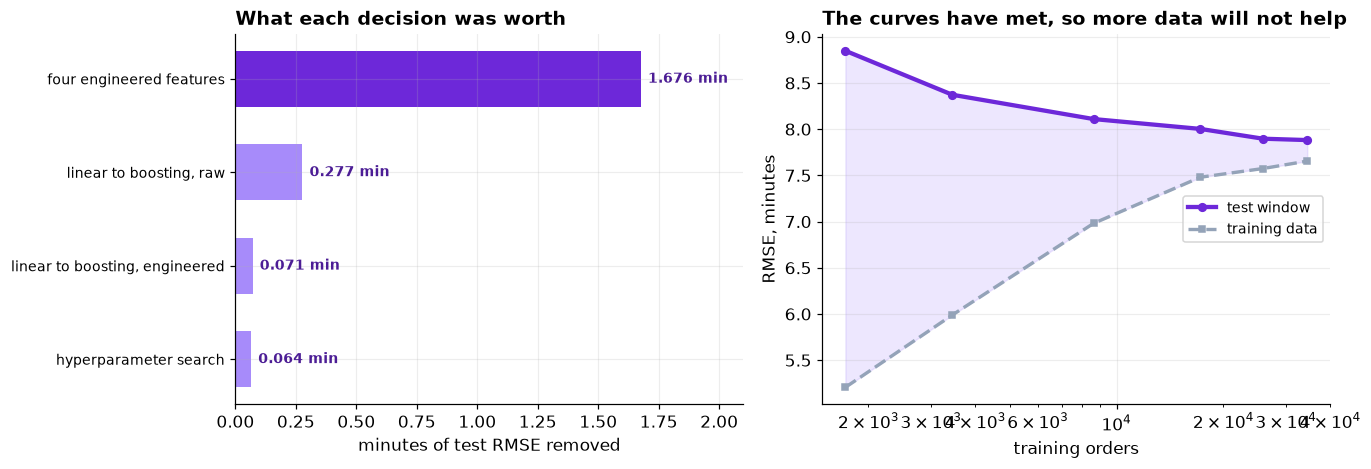

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.4))

ax = axes[0]
items = [("four engineered features", gbm_raw - gbm_eng), ("linear to boosting, raw", lin_raw - gbm_raw),
         ("hyperparameter search", gbm_eng - rmse), ("linear to boosting, engineered", lin_eng - gbm_eng)]
items.sort(key=lambda x: x[1])
yp = np.arange(len(items))
ax.barh(yp, [i[1] for i in items], color=[VI if i[1] > 1 else LT for i in items], height=0.6)
ax.set_yticks(yp); ax.set_yticklabels([i[0] for i in items], fontsize=9)
for i, (nm, v) in enumerate(items):
    ax.text(v + 0.03, i, f"{v:.3f} min", va="center", fontsize=9, fontweight="bold", color=DK)
ax.set_xlim(0, 2.1); ax.set_xlabel("minutes of test RMSE removed")
ax.set_title("What each decision was worth")

ax = axes[1]
ns  = [c[0] for c in curve]; rtr = [c[1] for c in curve]; rte = [c[2] for c in curve]
ax.plot(ns, rte, color=VI, lw=2.8, marker="o", ms=5, label="test window")
ax.plot(ns, rtr, color=MUT, lw=2.2, marker="s", ms=4, ls="--", label="training data")
ax.fill_between(ns, rtr, rte, color=LT, alpha=0.20)
ax.set_xscale("log"); ax.set_xlabel("training orders"); ax.set_ylabel("RMSE, minutes")
ax.set_title("The curves have met, so more data will not help")
ax.legend(fontsize=9, loc="center right")
plt.tight_layout(); plt.show()

**Left:** the three decisions every tabular project makes, priced in the same units. **Right:** the training and test curves converging, which is what tells you the remaining error is in the world rather than in the model.

## Step 12 &middot; What this does not settle

**The model is not the whole system.** It predicts what happens under current dispatching. If the platform starts showing longer times on hard orders, some customers will not order, which changes the load, which changes the predictions. A model that is used to make decisions eventually invalidates the data it was fitted on, and the holdout that would detect this has to be built deliberately.

**Eighty-four days is one season.** There is no winter in this dataset, no holiday peak and no restaurant closing down. The learning curve says more orders of the same kind will not help; it says nothing about orders of a different kind.

**The three-to-one cost ratio is an assertion.** It came from the operations team as a judgment, not a measurement, and the optimal quantile moves with it: at two to one the answer is the 67th percentile, at five to one it is the 83rd. That sensitivity is worth showing them, and it is a better conversation than arguing about the model.

**Displaying a wider window for hard orders has a business cost this analysis does not price.** A customer quoted 65 minutes may order somewhere else. That is a real effect, it is measurable with an experiment, and it is not in this dataset.

---

### What to take away

1. **The hierarchy was features, then model family, then hyperparameters**, and the gaps were roughly 100 seconds, 17 seconds and 4 seconds.
2. **One feature did all of it.** The three engineered features the model could have derived for itself were worth almost nothing; the one built by aggregating other rows was worth a minute and a half.
3. **Twenty configurations of search separated the top ten by four seconds on the test set**, and bought four seconds over the defaults.
4. **The learning curves met**, so the remaining error is in the world rather than in the model, and the answer is to communicate it rather than to chase it.
5. **The residual spread varies by a factor of two and a half** across ordinary operating conditions, and it is predictable.
6. **A flat buffer and a conditional quantile give the same overall late rate and completely different service.** The flat buffer's late rate ranges over 22 points across segments; the conditional version's over four.